# AA-UTE 2026

## P5 - Forecasting con transformers y variables exógenas

Este practico se centra en el uso de modelos de forecasting basados en transformers, específicamente el modelo PatchTST. Se utilizarán datos de la estación MER y se evaluará el desempeño del modelo utilizando métricas de error comunes.
Luego se comparará la diferencia cuando se agregan variables exógenas al modelo.

In [5]:
!pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Program Files\python.exe -m pip install --upgrade pip


In [6]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import time

from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import MSE

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [7]:
#---------------------------------------------------------------
# Métricas de evaluación para los modelos de forecasting.
# ---------------------------------------------------------------
def metricas(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }

In [10]:
# ---------------------------------------------------------------
# Carga de datos (Los mismos que el práctico anterior)
# ---------------------------------------------------------------
path_file = "./DATOS_15MIN_MER_trainset-labeled.csv"
dta = pd.read_csv(path_file, low_memory=False)
dta["timestamp"] = pd.to_datetime(dta["timestamp"])
dta.set_index("timestamp", inplace=True)
dta = dta[dta["series"] == "OFI"].copy()
dta = dta.drop(columns=["series", "label"])
dta = dta.resample("h").mean()
dta.head()

,value
timestamp,
2015-04-14 00:00:00+00:00,5.076925
2015-04-14 01:00:00+00:00,4.490550
2015-04-14 02:00:00+00:00,4.210925
2015-04-14 03:00:00+00:00,4.065475
2015-04-14 04:00:00+00:00,4.026950


# Variables exogenas (Hacer al final)

In [11]:
#Saltear esta celda hasta correr el modelo de transformers dado. Una vez finalizado el entrenamiento
# volver y completar la misma.
# #TODO: 
# 1 - Cargar los datos de temperatura para la estación Mercedes.
# 2 - Crear un dataframe con características de marcas de tiempos (ver practico anterior)
# 3 - Concatenar los dataframes de temperatura y marcas de tiempo con el dataframe dta.

# dta = pd.concat([dta, dta_w, dta_tf], axis=1)
# dta.head()

In [12]:
# ---------------------------------------------------------------
# Division de conjunto de entrenamiento y testeo
# ---------------------------------------------------------------

split_train_start = "2019-05-31"
split_train_end = "2020-05-31"
split_test_start = "2020-06-01"
split_test_end = "2020-06-30"

dta_train = dta.loc[split_train_start:split_train_end] # Por cuestiones de memoria y tiempo solo utilizaremos 1 año para entrenar.
dta_test = dta.loc[split_test_start:split_test_end]

# Se lleva los datos a formato largo
dta_nf = dta_train.reset_index().rename(columns={"timestamp": "ds", "value": "y"})
dta_nf["unique_id"] = "MER"

dta_test_nf = dta_test.reset_index().rename(columns={"timestamp": "ds", "value": "y"})
dta_test_nf["unique_id"] = "MER"

### Entrenamiento con modelo de transformer (PatchTST)

En las siguientes celdas se entrena un modelo de transformer (PatchTST) con los datos de la esación MER.

In [13]:
# ---------------------------------------------------------------
# Definición de los modelos con sus hiperparámetros.
# ---------------------------------------------------------------

H = 168 # Se define la ventana de predicción como 1 semana (168 horas).
INPUT_SIZE = 2 * 168 # Se define la ventana de entrada como 2 semanas (336 horas).

fcst = NeuralForecast(
    models=[
            PatchTST(h=H,
                input_size=INPUT_SIZE,
                max_steps=500,
                val_check_steps=50,
                early_stop_patience_steps=3,
                loss=MSE(),
                valid_loss=MSE(),
                ),
    ],
    freq='h'
)

Seed set to 1


In [14]:
# ---------------------------------------------------------------
# Entrenamiento del modelo 
# ---------------------------------------------------------------

t0 = time.perf_counter()
fcst.fit(df=dta_nf, val_size=720 * 3)
patchtst_train_time = time.perf_counter() - t0

print(f"Tiempo entrenamiento PatchTST: {patchtst_train_time:.2f}s")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type              | Params | Mode  | FLOPs
--------------------------------------------------------------------------
0 | loss                | MSE               | 0      | train | 0    
1 | valid_loss          | MSE               | 0      | train | 0    
2 | hist_cat_embeddings | ModuleList        | 0      | train | 0    
3 | futr_cat_embeddings | ModuleList        | 0      | train | 0    
4 | stat_cat_embeddings | ModuleList        | 0      | train | 0    
5 | padder_train        | ConstantPad1d     | 0      | train | 0    
6 | scaler              | TemporalNorm      | 0      | train | 0    
7 | model               | PatchTST_backbone | 1.3 M  | train | 0    
--------------------------------------------------------------------------
1.3 M     Trainable params
3         Non-trainable params
1.3 M     Total params
5.233     Total estimated model params size (MB)
94        Modules in tr

Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\ut605453\AppData\Local\miniconda3\envs\ts_ute_b\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


C:\Users\ut605453\AppData\Local\miniconda3\envs\ts_ute_b\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 49: 100%|██████████| 1/1 [00:02<00:00,  0.38it/s, v_num=0, train_loss_step=0.354, train_loss_epoch=0.372]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 99: 100%|██████████| 1/1 [00:02<00:00,  0.39it/s, v_num=0, train_loss_step=0.335, train_loss_epoch=0.323, valid_loss=0.267]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 149: 100%|██████████| 1/1 [00:02<00:00,  0.40it/s, v_num=0, train_loss_step=0.311, train_loss_epoch=0.311, valid_loss=0.266]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 199: 100%|██████████| 1/1 [00:02<00:00,  0.38it/s, v_num=0, train_loss_step=0.306, train_loss_epoch=0.293, valid_loss=0.261]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 249: 100%|██████████| 1/1 [00:02<00:00,  0.33it/s, v_num=0, train_loss_step=0.292, train_loss_epoch=0.292, valid_loss=0.29

In [15]:
# ---------------------------------------------------------------
# Predicciones de las primeras semanas del conjunto de test.
# ---------------------------------------------------------------

def rolling_weekly_predict(fcst_model, serie, model_name, start="2020-06-01 00:00:00+00:00", h=168, input_size=2 * 168):
    i = serie.index.get_loc(start)
    forecasts_to_compare = pd.DataFrame()

    for m in range(4):
        df = serie.iloc[max(0, i + (h * m) - input_size): i + (h * m)].copy()
        df_nf = df.reset_index().rename(columns={"timestamp": "ds", "value": "y"})
        df_nf["unique_id"] = "MER"
        forecast = fcst_model.predict(df=df_nf)
        forecasts_to_compare = pd.concat([forecasts_to_compare, forecast], ignore_index=False)

    forecasts_to_compare = forecasts_to_compare.set_index("ds").sort_index()
    return forecasts_to_compare[[model_name]]


pred_patch_june = rolling_weekly_predict(fcst, dta, "PatchTST", h=H, input_size=INPUT_SIZE)
print(pred_patch_june.head())

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\ut605453\AppData\Local\miniconda3\envs\ts_ute_b\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 71.22it/s]

C:\Users\ut605453\AppData\Local\miniconda3\envs\ts_ute_b\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 142.48it/s]

C:\Users\ut605453\AppData\Local\miniconda3\envs\ts_ute_b\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 94.91it/s] 


C:\Users\ut605453\AppData\Local\miniconda3\envs\ts_ute_b\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 79.51it/s]
                           PatchTST
ds                                 
2020-06-01 00:00:00+00:00  3.981734
2020-06-01 01:00:00+00:00  3.640076
2020-06-01 02:00:00+00:00  3.341663
2020-06-01 03:00:00+00:00  3.196863
2020-06-01 04:00:00+00:00  3.190150


In [16]:
june_test = dta[split_test_start:split_test_end].copy()

idx_patch = june_test.index.intersection(pred_patch_june.index)
metrics_patch_1w = metricas(june_test.loc[idx_patch, "value"].values, pred_patch_june.loc[idx_patch, "PatchTST"].values)

In [21]:
print(pred_patch_june.columns)

Index(['PatchTST'], dtype='str')


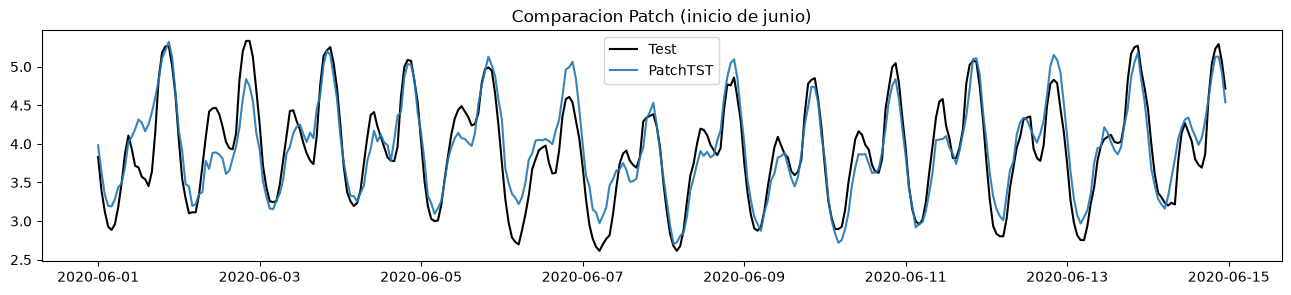

In [22]:
plt.figure(figsize=(16, 3))
plt.plot(june_test.index[:24 * 14], june_test["value"].values[:24 * 14], label="Test", color="black")
plt.plot(pred_patch_june.index[:24 * 14], pred_patch_june["PatchTST"].values[:24 * 14], label="PatchTST", alpha=0.9)
plt.title("Comparacion Patch (inicio de junio)")
plt.legend(loc="best")
plt.show()

### Variables exógenas en modelos de forecasting con Transformers.

RESPONDER: 
A partir del siguiente ejemplo: https://nixtlaverse.nixtla.io/neuralforecast/docs/capabilities/exogenous_variables.html

1. ¿Qué son las variables exógenas pasadas y futuras?


EXPERIMENTAR:
 Agregar variables exógenas a un nuevo modelo PatchTST y evaluar el impacto en las métricas de evaluación.

1. Cargar los datos de temperatura para la estación Mercedes.
2. Crear un dataframe con características de marcas de tiempos (ver práctico anterior).
3. Concatenar los dataframes de temperatura y marcas de tiempo con el dataframe `dta`.
4. Entrenar un nuevo modelo `PatchTST` con las variables exógenas.
5. Comparar las métricas obtenidas con y sin variables exógenas.


RESPUESTAS:

las exogenas futuras son 

EXPERIMENTAR:
Si todavia le queda tiempo, seleccionar algún otro modelo de tranformers y repetir el experimento.

https://nixtlaverse.nixtla.io/neuralforecast/docs/capabilities/overview.html